# Granite for Bike Rental Predictions

This notebook explores using granite to obtain regional explanations on the BikeSharing dataset.
## Setup

In [48]:
import os

import numpy as np
import matplotlib.pyplot as plt
from joblib import dump, load
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import root_mean_squared_error

# granite imports
from granite.data import get_data_bike
from granite.experiments import MinimizeSuperset
from granite.decompositions import get_components_tree
from granite.plots import partial_dependence_plot

### Input Features

The BikeSharing dataset aims to predict the hourly count of bike rentals between years 2011
and 2012 in Washington state, based on time and weather features. It involves 17K instances
and 10 features.

First load the data and a `Features` object that stores information about the various features. 
Note that the data **X** must **always** be a numerical numpy array. Categorical features are assumed 
to have been ordinally encoded.

In [49]:
# Built-in function for the BikeSharing dataset
X, y, features = get_data_bike()
# Make months and weekdays smaller for the plots (optional)
features.feature_objs[1].cats = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
features.feature_objs[4].cats = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
features.summary()

|Idx|        Name        |        Type        |    Card    |      Groups      |
-------------------------------------------------------------------------------
| 0 | yr                 | ordinal            | 2          | [0]              |
| 1 | mnth               | ordinal            | 12         | [1]              |
| 2 | hr                 | num_int            | 24         | [2]              |
| 3 | holiday            | bool               | 2          | [3]              |
| 4 | weekday            | ordinal            | 7          | [4]              |
| 5 | workingday         | bool               | 2          | [5]              |
| 6 | weathersit         | num_int            | 4          | [6]              |
| 7 | temp               | num                | inf        | [7]              |
| 8 | hum                | num                | inf        | [8]              |
| 9 | windspeed          | num                | inf        | [9]              |
----------------------------------------

This dataset involves 10 features of various types. The following Table can help understand their meaning and domain.

<p align="center">
    <img src="./Images/Features_bike.png" width="600">
</p>

### Get the model
Having fetched the data, we fit a `HistGradientBoostingRegressor`.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = HistGradientBoostingRegressor(random_state=0)

In [51]:
os.makedirs("models", exist_ok=True)
model_path = os.path.join("models", "bike_gbt.joblib")

if os.path.exists(model_path):
    print("Model already exists. Loading from disk.")
    model = load(model_path)
else:
    print("Training the model...")
    grid = {"learning_rate": np.logspace(-2, 0, 10),
            "max_depth" : [3, 4, 5, 6, 7],
            "max_iter" : [50, 100, 150, 200],
            'min_samples_leaf' : [1, 20, 40, 60, 80, 100]}

    search = RandomizedSearchCV(
        model,
        cv=KFold(),
        scoring='neg_root_mean_squared_error',
        param_distributions=grid,
        verbose=2,
        n_iter=20,
        random_state=42
    )
    search.fit(X_train, y_train)
    display(search)

    # get the model with the best hyperparameters
    model = search.best_estimator_
    dump(model, model_path)

    # visualize the results
    res = search.cv_results_
    cv_perf = np.nan_to_num(-res['mean_test_score'], nan=1e10)
    best_idx = np.argmin(cv_perf)
    plt.scatter(res['param_learning_rate'], cv_perf, c='b', alpha=0.75)
    plt.plot(res['param_learning_rate'][best_idx], cv_perf[best_idx], 'r*', markersize=10, markeredgecolor='k')
    plt.xlabel("Learning Rate")
    plt.ylabel("Cross-Validated RMSE")
    plt.xscale('log')
    plt.show()

test_preds = model.predict(X_test)
print(f" RMSE of the model : {root_mean_squared_error(test_preds, y_test):.2f}")
print(f" Std dev of the target : {y_test.std():.2f}")

Model already exists. Loading from disk.
 RMSE of the model : 43.08
 Std dev of the target : 181.45


## Computing Marginal Pure-Full Effects

We can understand how individual features impact the model response by computing their pure and full marginal effects. Here we study the 7th feature `temp`.

In [52]:
# Compute the H^k matrices using a subset of 1000 training points
background = X_train[:2000]
decomposition = get_components_tree(model, background, background, features.select([7]), anchored=True)

[################################################  ] 96%

###] 100%

In [53]:
# The keys are tuples encoding subsets of features
display(decomposition.keys())
# The () key is the intercept
display(decomposition[()].shape)
# The key (0,) is the main effect of 7, the only feature given to the decomposition
display(decomposition[(0,)].shape)

dict_keys([(), (0,)])

(2000,)

(2000, 2000)

For instance we can investigate how `temp` affects the model output.

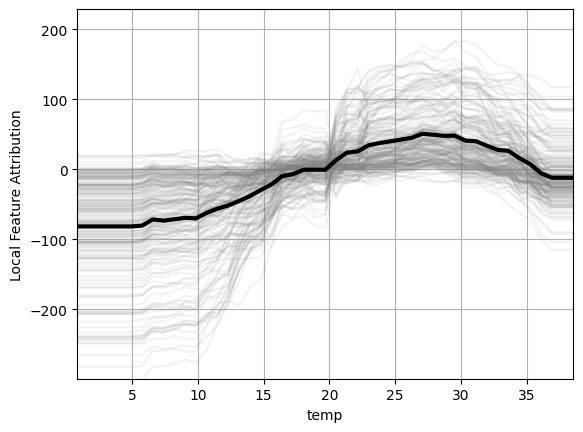

In [54]:
# We plot the h_i terms along side the Shapley Values
partial_dependence_plot(decomposition, background, features.select([7]), centered=True)

In this plot, the dark line is the PDP while the thin lines are the ICEs. Difference between the two are indicators of feature interactions involving `temp`. This means that the effect of increasing/decreasing temperature depends on the value of
other features. Our local explanations should account for these interactions.

In [55]:
# Split along remaining features to minimize superset error
features_to_split_upon = [i for i in range(len(features)) if not i == 7]
tree = MinimizeSuperset(max_depth=3, features=features.select(features_to_split_upon), alpha=0.07)
tree.fit(background[:, features_to_split_upon], decomposition, u=(0,))
tree.print(verbose=True)

Loss 1.0597
Samples 2000
If hr ≤ 10.0000:
|   Loss 0.1488
|   Samples 883
|   Region 0
else:
|   Loss 0.5527
|   Samples 1117
|   If mnth ≤ 1.0000:
|   |   Loss 0.0278
|   |   Samples 167
|   |   Region 1
|   else:
|   |   Loss 0.3420
|   |   Samples 950
|   |   If mnth ≤ 9.0000:
|   |   |   Loss 0.1955
|   |   |   Samples 767
|   |   |   Region 2
|   |   else:
|   |   |   Loss 0.0444
|   |   |   Samples 183
|   |   |   Region 3
Final Loss 0.4165


In [56]:
# Using regional backgrounds
larger_background = X[:4000]
regions = tree.predict(larger_background[:, features_to_split_upon])
print(np.unique(regions, return_counts=True))
rules = tree.rules()
print(rules)

(array([0, 1, 2, 3], dtype=int32), array([1835,  358, 1429,  378]))
{0: 'hr<=10.00', 1: '(hr>10.00 & mnth ∈ {Jan,Feb})', 2: '(hr>10.00 & mnth ∈ {Mar,Apr,May,Jun,Jul,Aug,Sep,Oct})', 3: '(hr>10.00 & mnth ∈ {Nov,Dec})'}


In [57]:
# We compute regional decompositions
regional_backgrounds = [[]] * tree.n_regions
regional_decomposition = [[]] * tree.n_regions
for r in range(tree.n_regions):
    regional_backgrounds[r] = larger_background[regions==r]
    # Regional Decomposition
    regional_decomposition[r] = get_components_tree(
        model,
        regional_backgrounds[r],
        regional_backgrounds[r],
        features.select([7]),
        anchored=True
    )

[##################################################] 100%[#######                                           ] 15%

###########################################] 100%

[##################################################] 100%[####                                              ] 8%

#########################                      ] 57%

######################] 100%

Explaining:  36%|███▌      | 36/100 [01:26<02:33,  2.40s/it]


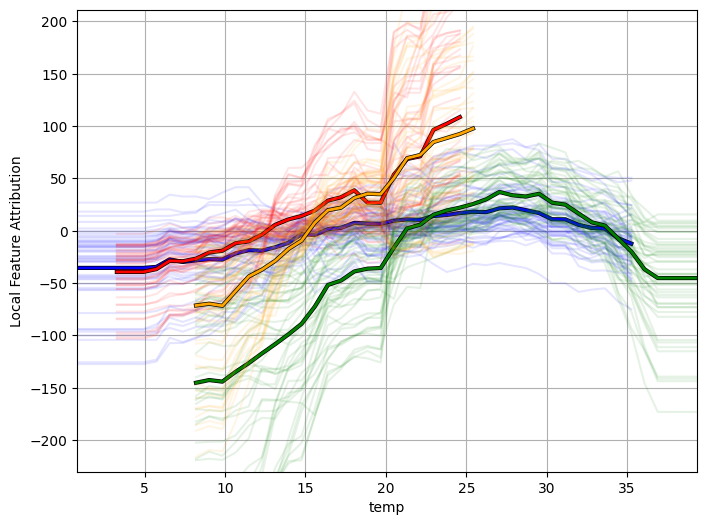

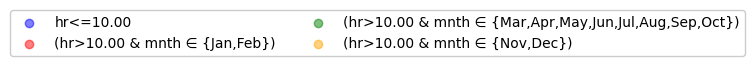

In [58]:
from granite.plots import plot_legend

# Regional h_i and SHAP values
partial_dependence_plot(regional_decomposition, regional_backgrounds, features.select([7]), centered=True, figsize=(8, 6))
plot_legend(rules, ncol=2)

## Explain with shapiq
Now that we have identified the regions and computed the regional decompositions, we can use shapiq to explain the model's predictions in each region. We will explain with the 2nd order Faithful Interaction Index (FSII). For each region, we will explain a set of samples from the regional background and then explain the remaining samples in that region.

In [72]:
from shapiq import TabularExplainer, InteractionValues

n_features = len(features)
ivs: dict[int, list[InteractionValues]] = {}
x_explains: dict[int, np.ndarray] = {}

for r in range(tree.n_regions):
    x_regional_background = regional_backgrounds[r]
    x_explain = x_regional_background[:100]
    x_explains[r] = x_explain.copy()
    data = x_regional_background[100:]
    explainer = TabularExplainer(
        model,
        data=data,
        approximator="regression",
        index="FSII",
        max_order=2,
    )
    ivs_region = explainer.explain_X(X=x_explain, budget=2**n_features, verbose=True)
    display(f"Region {r} - {len(x_regional_background)} samples - rule: {rules[r]}")
    display(f"Explained {len(ivs_region)}")
    display(f"First interaction value: ")
    print(ivs_region[0])
    ivs[r] = ivs_region

Explaining: 100%|██████████| 100/100 [01:11<00:00,  1.39it/s]


'Region 0 - 1835 samples - rule: hr<=10.00'

'Explained 100'

'First interaction value: '

InteractionValues(
    index=FSII, max_order=2, min_order=0, estimated=False, estimation_budget=1024,
    n_players=10, baseline_value=106.28360312073835,
    Top 10 interactions:
        (): 106.28360312073835
        (0, 2): 14.73043723426303
        (6,): -11.536065604972984
        (8,): -13.26271890231485
        (3,): -15.195761040667806
        (9,): -16.95952393586249
        (2, 5): -19.331039174484843
        (7,): -27.36469776573867
        (0,): -29.59897565725462
        (2,): -57.09852116533624
)


...

Explaining: 100%|██████████| 100/100 [01:07<00:00,  1.48it/s]


'Region 3 - 378 samples - rule: (hr>10.00 & mnth ∈ {Nov,Dec})'

'Explained 100'

'First interaction value: '

InteractionValues(
    index=FSII, max_order=2, min_order=0, estimated=False, estimation_budget=1024,
    n_players=10, baseline_value=206.9678450504047,
    Top 10 interactions:
        (): 206.9678450504047
        (2, 5): 56.75793401141467
        (0,): 54.54447399579615
        (2, 4): 32.383256122498636
        (4,): 19.597118178205957
        (1, 9): 12.224884640288245
        (0, 4): 11.708034849930987
        (5,): -11.996586470659887
        (1,): -12.003332253685548
        (7,): -12.745356475670043
)


## Visualizations in shapiq
Here follows a collection of visualizations that can be used from shapiq.

In [74]:
# imports
from shapiq.interaction_values import aggregate_interaction_values

from shapiq.plot import (
    bar_plot,  # global plot
    beeswarm_plot,  # global plot
    si_graph_plot,
    force_plot,
    waterfall_plot,
    upset_plot,
    stacked_bar_plot
)

avg_iv = {
    r: aggregate_interaction_values(ivs, aggregation="mean")
    for r, ivs in ivs.items()
}

### Bar Plot (global plot)
We can visualize a global explanation as a bar plot. The bars represent the absolute value of the interaction values, which indicate the importance of each feature in the model's prediction for that region.

'Region 0 - rule: hr<=10.00'

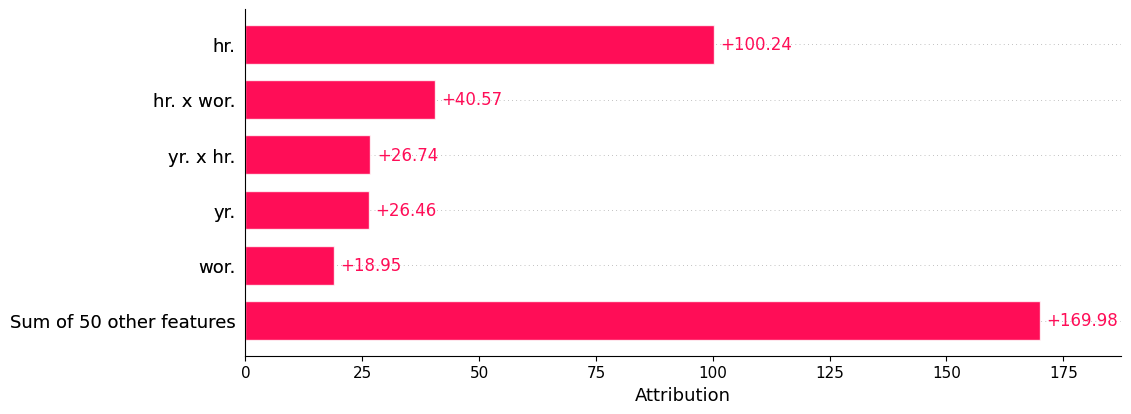

'Region 1 - rule: (hr>10.00 & mnth ∈ {Jan,Feb})'

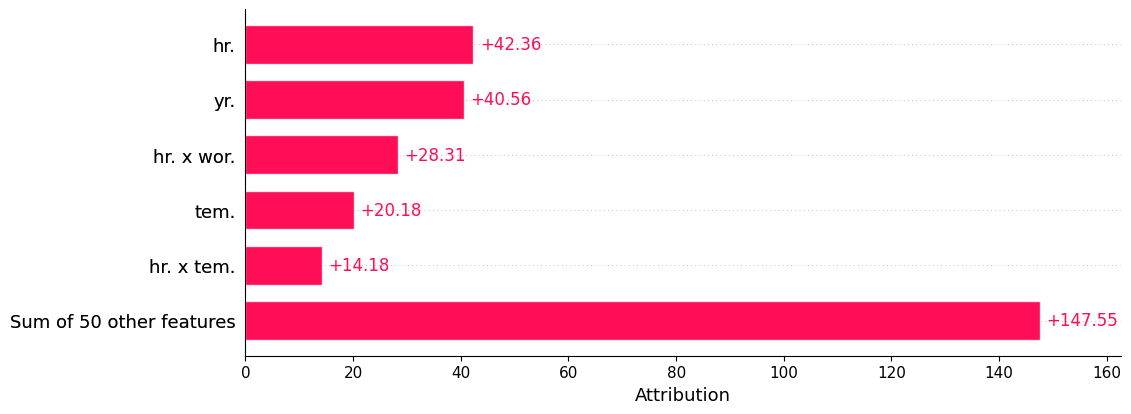

'Region 2 - rule: (hr>10.00 & mnth ∈ {Mar,Apr,May,Jun,Jul,Aug,Sep,Oct})'

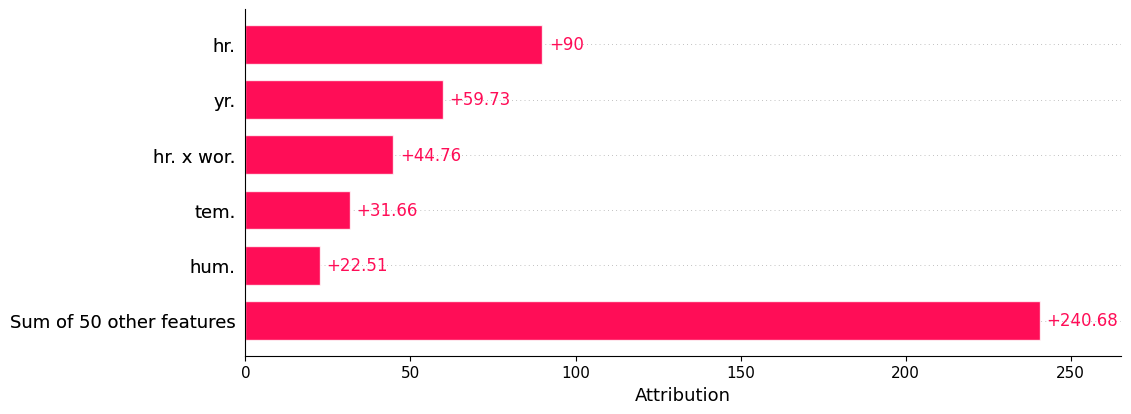

'Region 3 - rule: (hr>10.00 & mnth ∈ {Nov,Dec})'

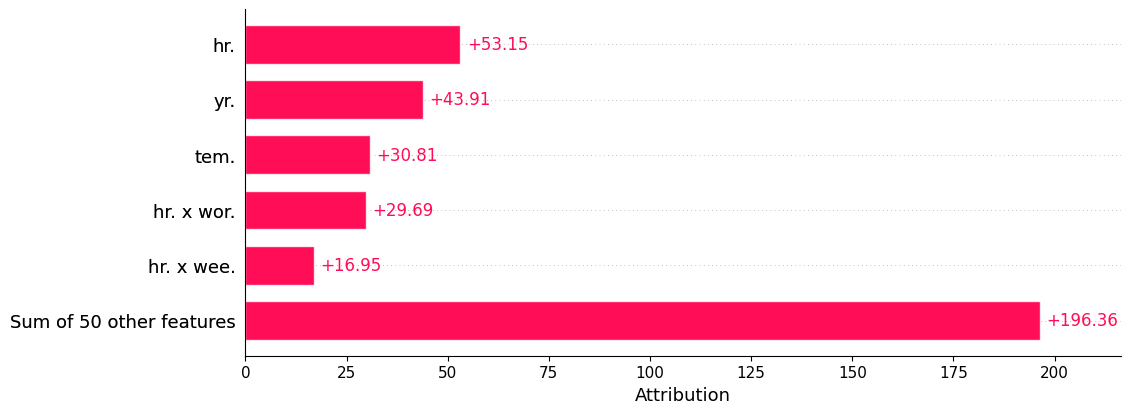

In [75]:
for r, ivs_region in ivs.items():
    display(f"Region {r} - rule: {rules[r]}")
    bar_plot(ivs_region, show=True, feature_names=features.names(), max_display=5)

### Beesvarm plot (global plot)
The beeswarm plot provides a more detailed view of the interaction values, showing the distribution of interaction values for each feature across the samples in the region. Each point represents an interaction value for a sample, and the color indicates the feature.

'Region 0 - rule: hr<=10.00'

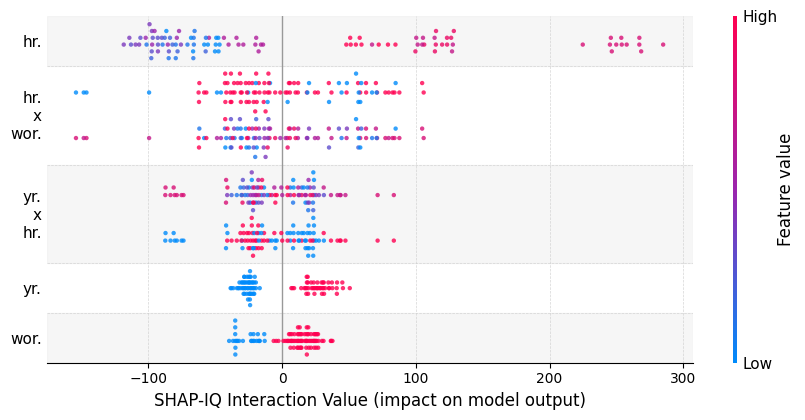

'Region 1 - rule: (hr>10.00 & mnth ∈ {Jan,Feb})'

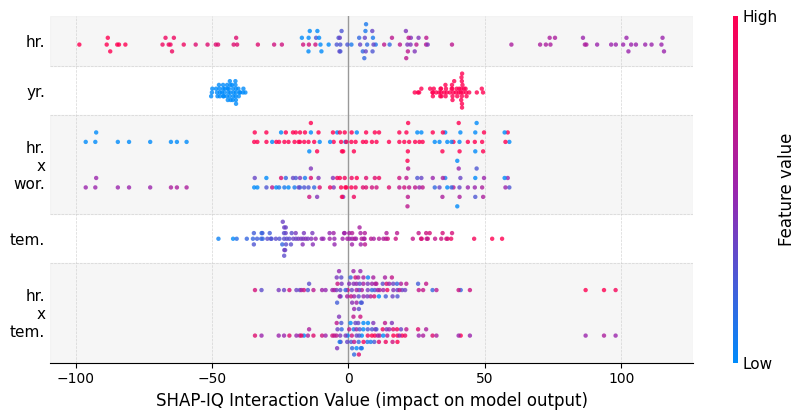

'Region 2 - rule: (hr>10.00 & mnth ∈ {Mar,Apr,May,Jun,Jul,Aug,Sep,Oct})'

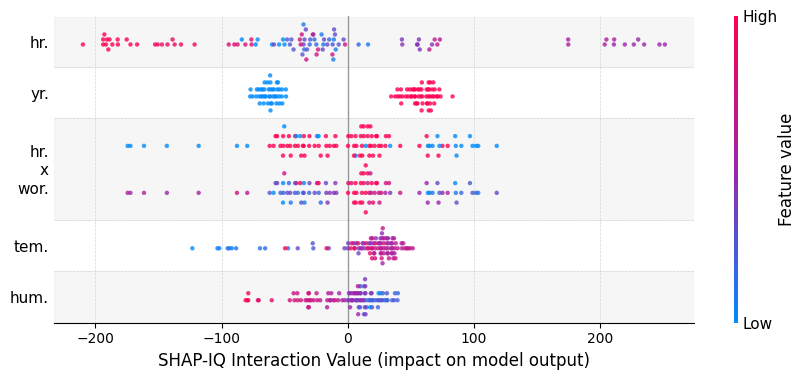

'Region 3 - rule: (hr>10.00 & mnth ∈ {Nov,Dec})'

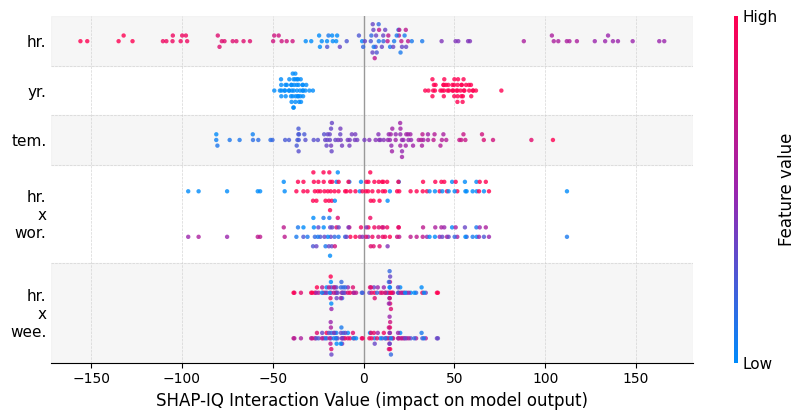

In [76]:
for r, ivs_region in ivs.items():
    display(f"Region {r} - rule: {rules[r]}")
    x_explain = x_explains[r]
    beeswarm_plot(ivs_region, data=x_explain, show=True, feature_names=features.names(), max_display=5)

### Stacked Bar Plot (local plot)
The stacked bar plot shows for each interaction order the sum of interaction scores in the positive and negative directions.

'Region 0 - rule: hr<=10.00'

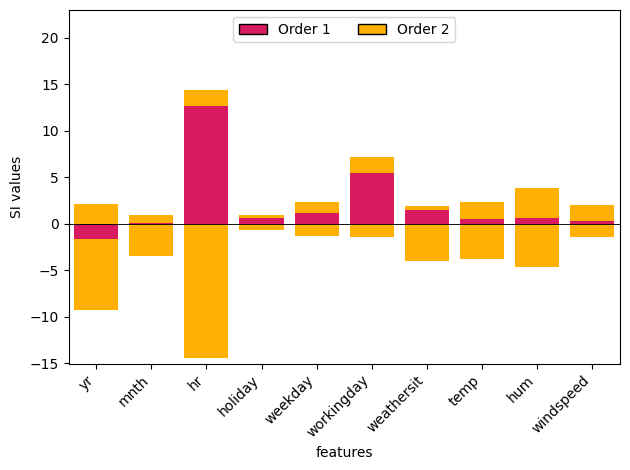

'Region 1 - rule: (hr>10.00 & mnth ∈ {Jan,Feb})'

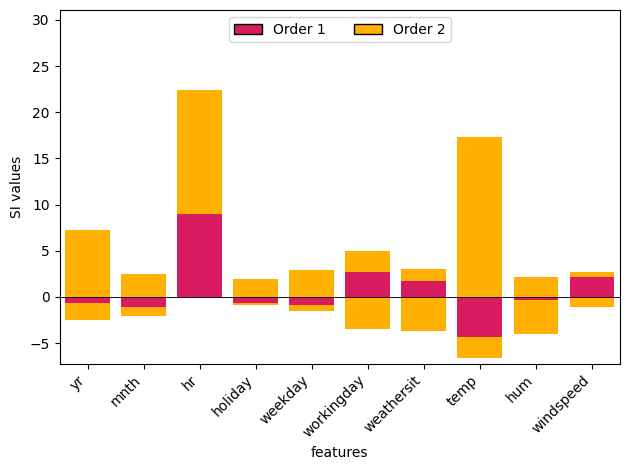

'Region 2 - rule: (hr>10.00 & mnth ∈ {Mar,Apr,May,Jun,Jul,Aug,Sep,Oct})'

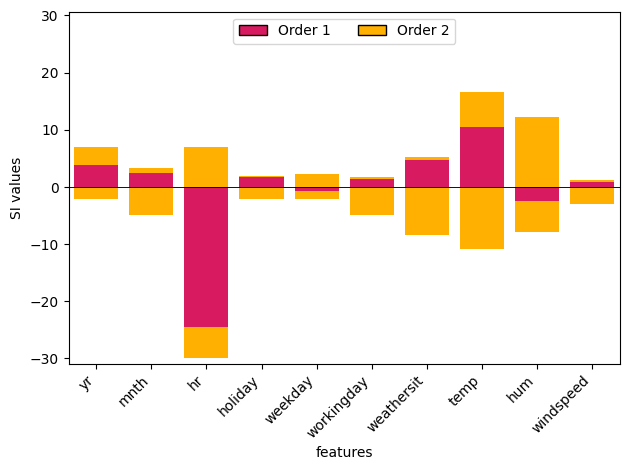

'Region 3 - rule: (hr>10.00 & mnth ∈ {Nov,Dec})'

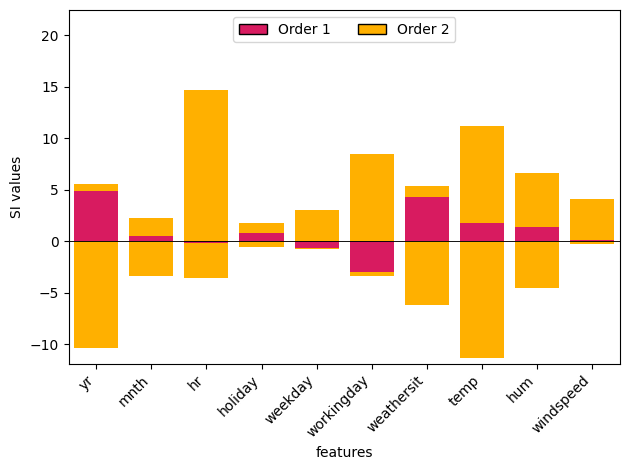

In [82]:
for r, ivs_region in avg_iv.items():
    display(f"Region {r} - rule: {rules[r]}")
    stacked_bar_plot(ivs_region, show=True, feature_names=features.names())

### SI-Graph (local plot)
The SI-Graph is a local visualization that shows the interaction values for a specific sample. It plots the interactions as a hypergraph, where edges represent interaction strengths between features and nodes represents main effects.

'Region 0 - rule: hr<=10.00'

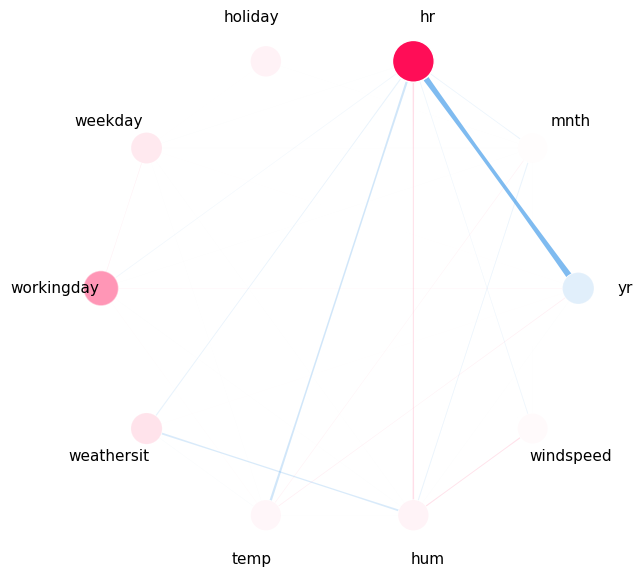

'Region 1 - rule: (hr>10.00 & mnth ∈ {Jan,Feb})'

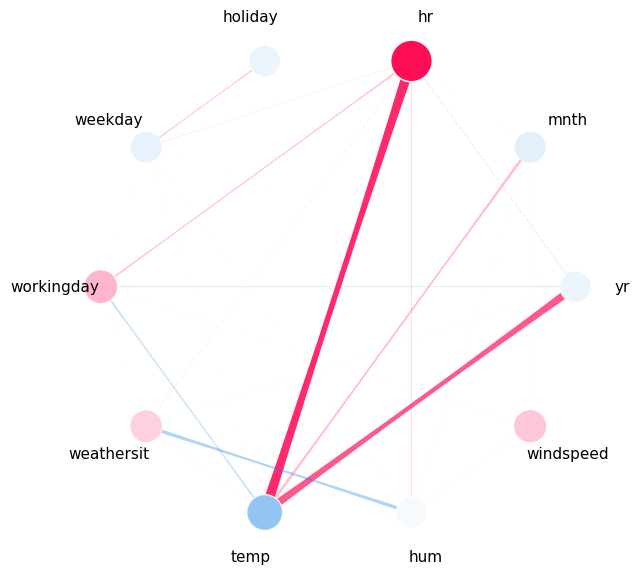

'Region 2 - rule: (hr>10.00 & mnth ∈ {Mar,Apr,May,Jun,Jul,Aug,Sep,Oct})'

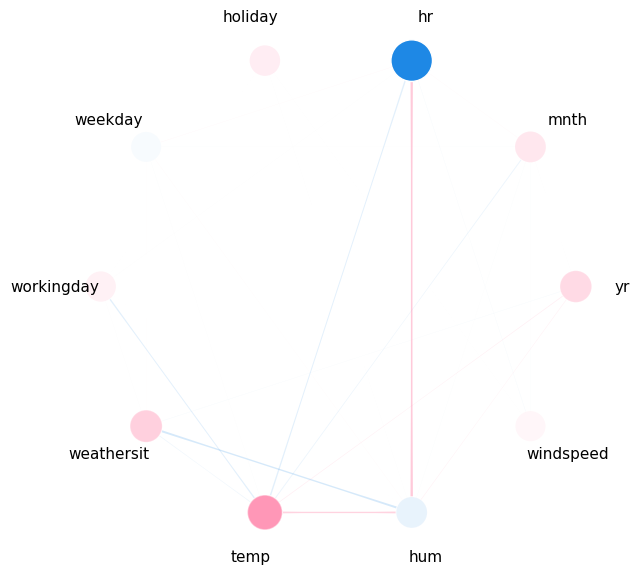

'Region 3 - rule: (hr>10.00 & mnth ∈ {Nov,Dec})'

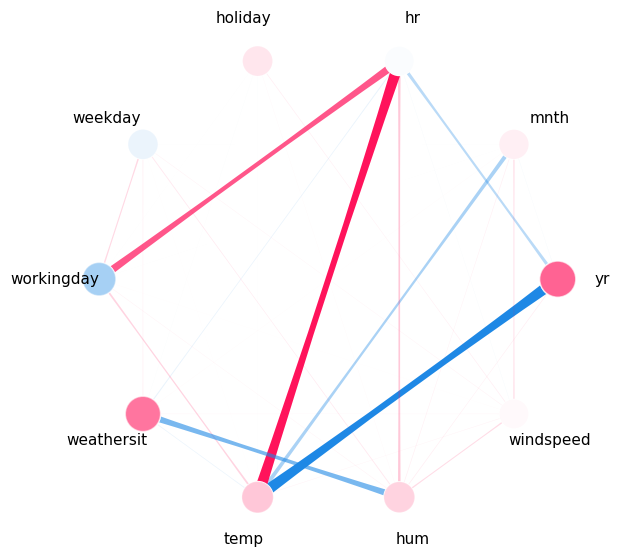

In [78]:
for r, ivs_region in avg_iv.items():
    display(f"Region {r} - rule: {rules[r]}")
    si_graph_plot(ivs_region, show=True, feature_names=features.names())

### Force Plot (local plot)
The force plot visualizes the contribution of each feature to the model's prediction for a specific sample. It shows how each feature pushes the prediction up or down from the baseline.

'Region 0 - rule: hr<=10.00'

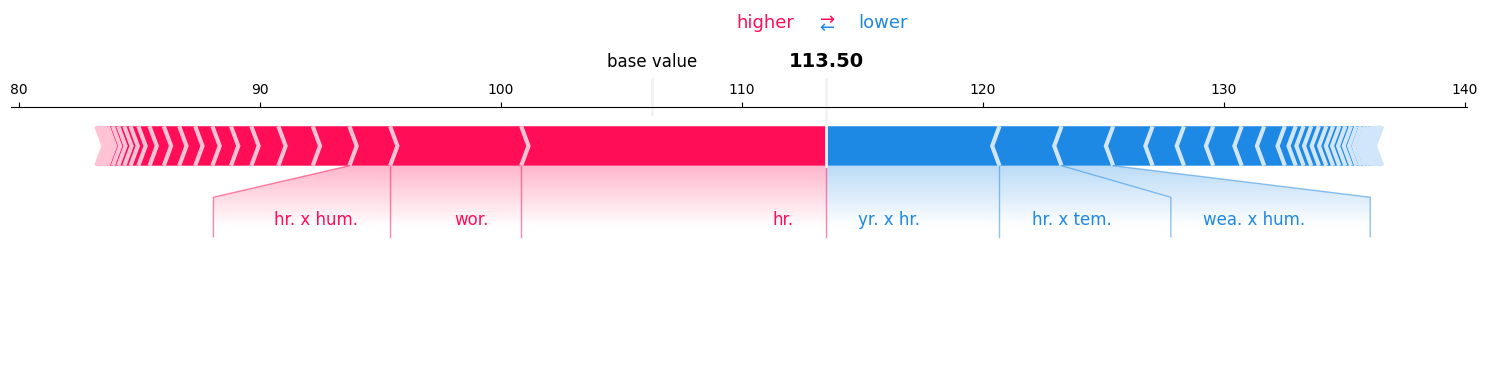

'Region 1 - rule: (hr>10.00 & mnth ∈ {Jan,Feb})'

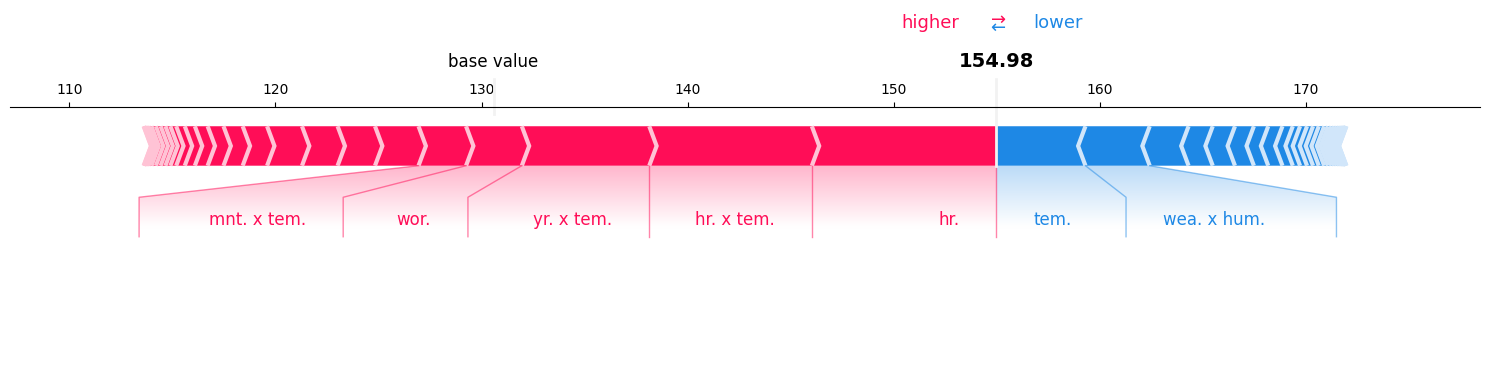

'Region 2 - rule: (hr>10.00 & mnth ∈ {Mar,Apr,May,Jun,Jul,Aug,Sep,Oct})'

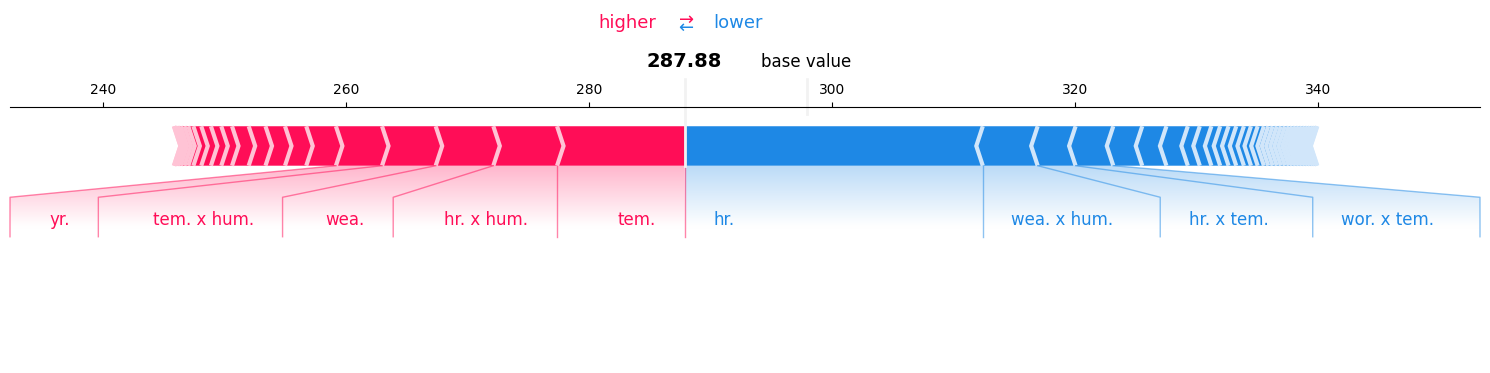

'Region 3 - rule: (hr>10.00 & mnth ∈ {Nov,Dec})'

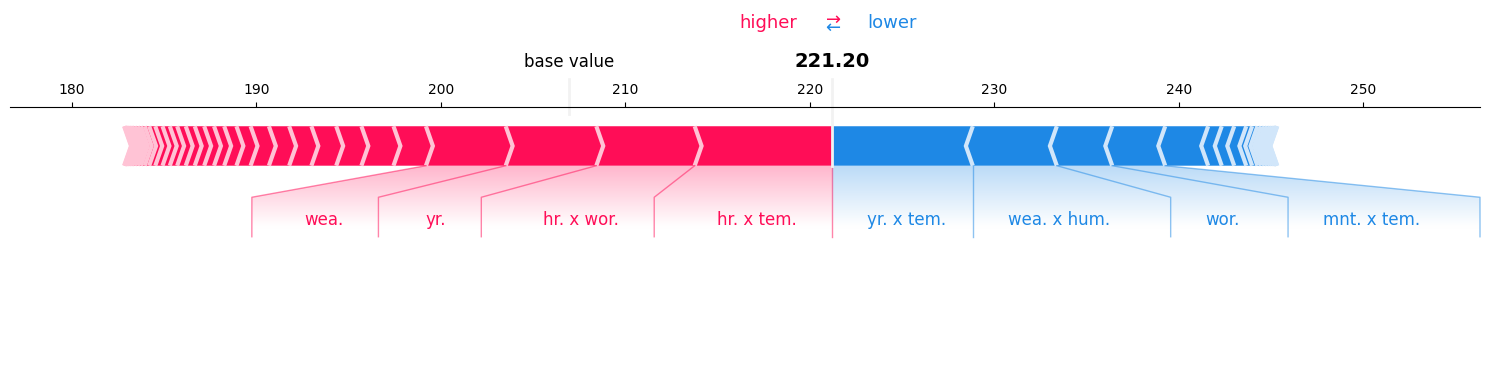

In [79]:
for r, ivs_region in avg_iv.items():
    display(f"Region {r} - rule: {rules[r]}")
    force_plot(ivs_region, show=True, feature_names=features.names())

### Waterfall Plot (local plot)
The waterfall plot is another version of the force plot, which displays the contributions of each feature in a stacked manner.

'Region 0 - rule: hr<=10.00'

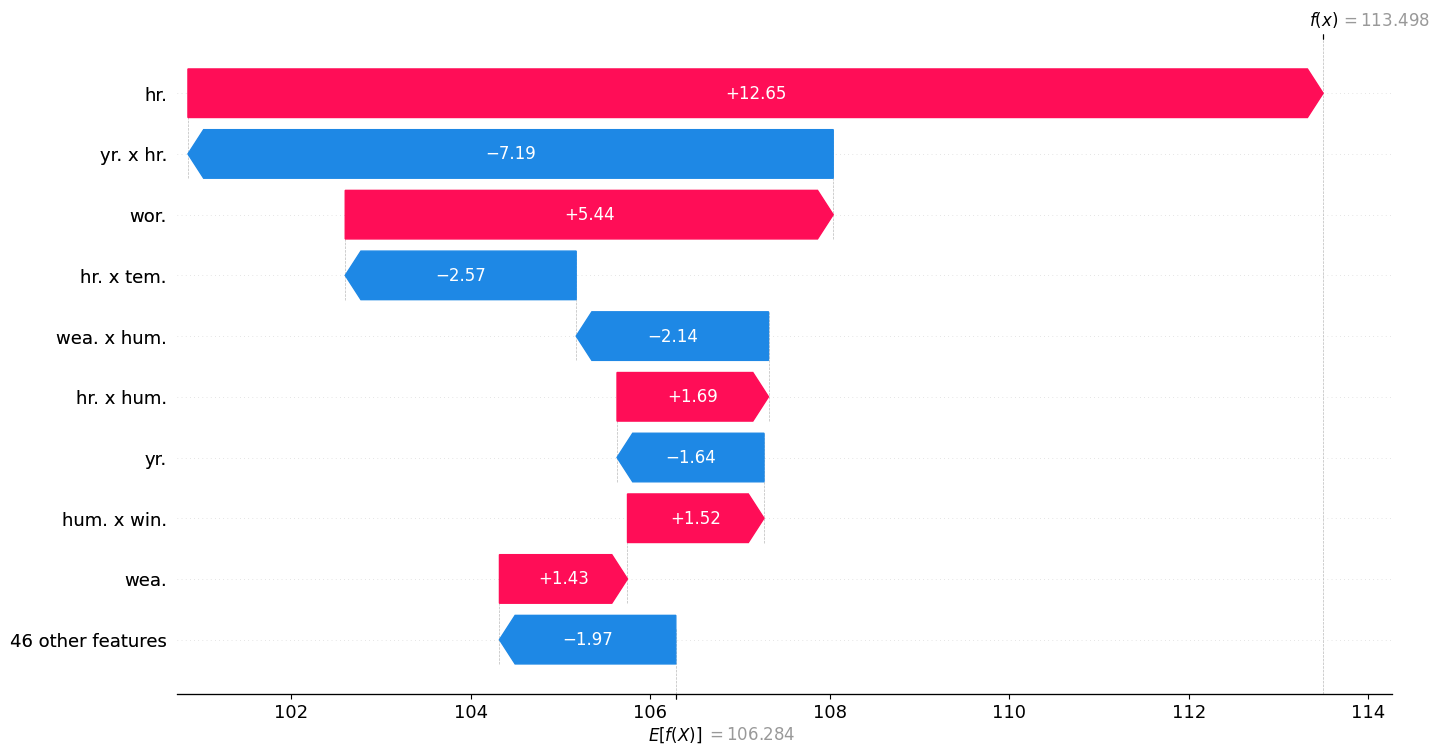

'Region 1 - rule: (hr>10.00 & mnth ∈ {Jan,Feb})'

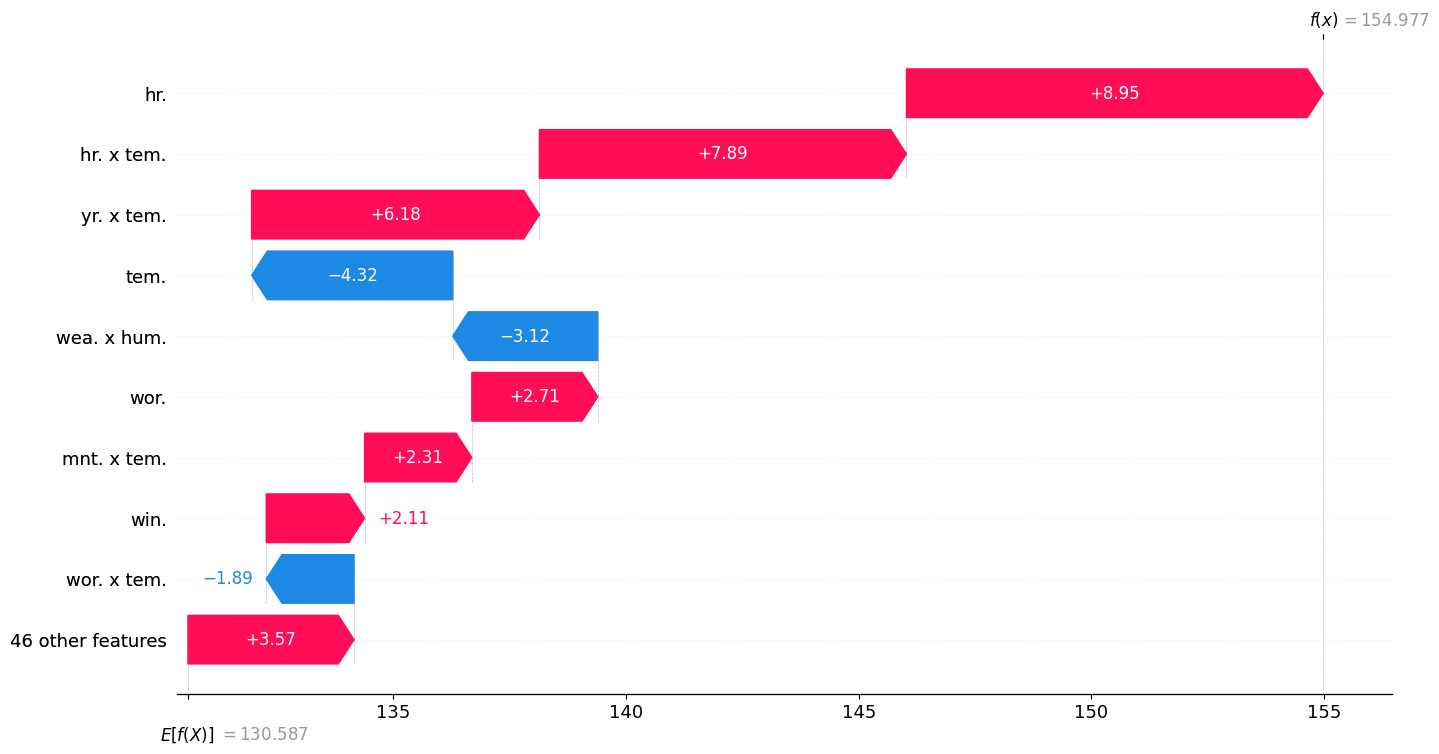

'Region 2 - rule: (hr>10.00 & mnth ∈ {Mar,Apr,May,Jun,Jul,Aug,Sep,Oct})'

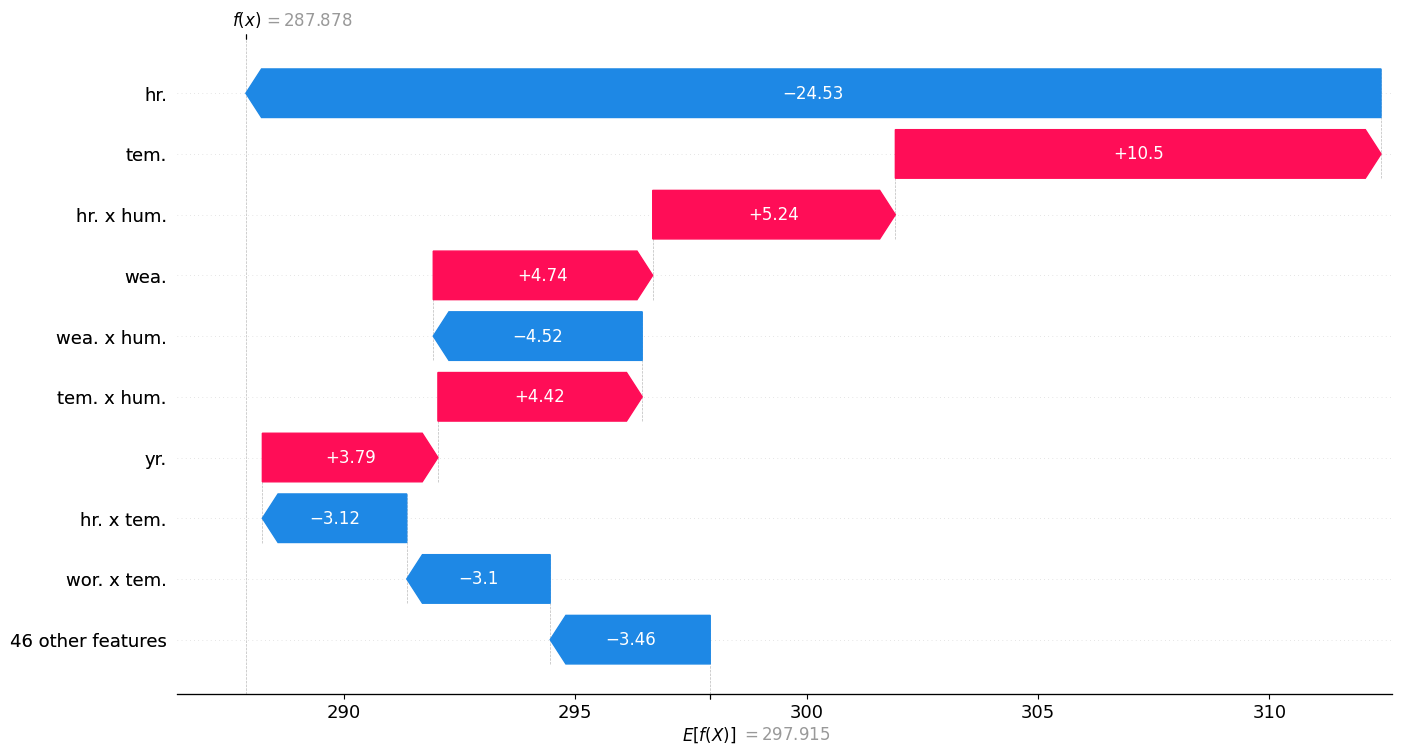

'Region 3 - rule: (hr>10.00 & mnth ∈ {Nov,Dec})'

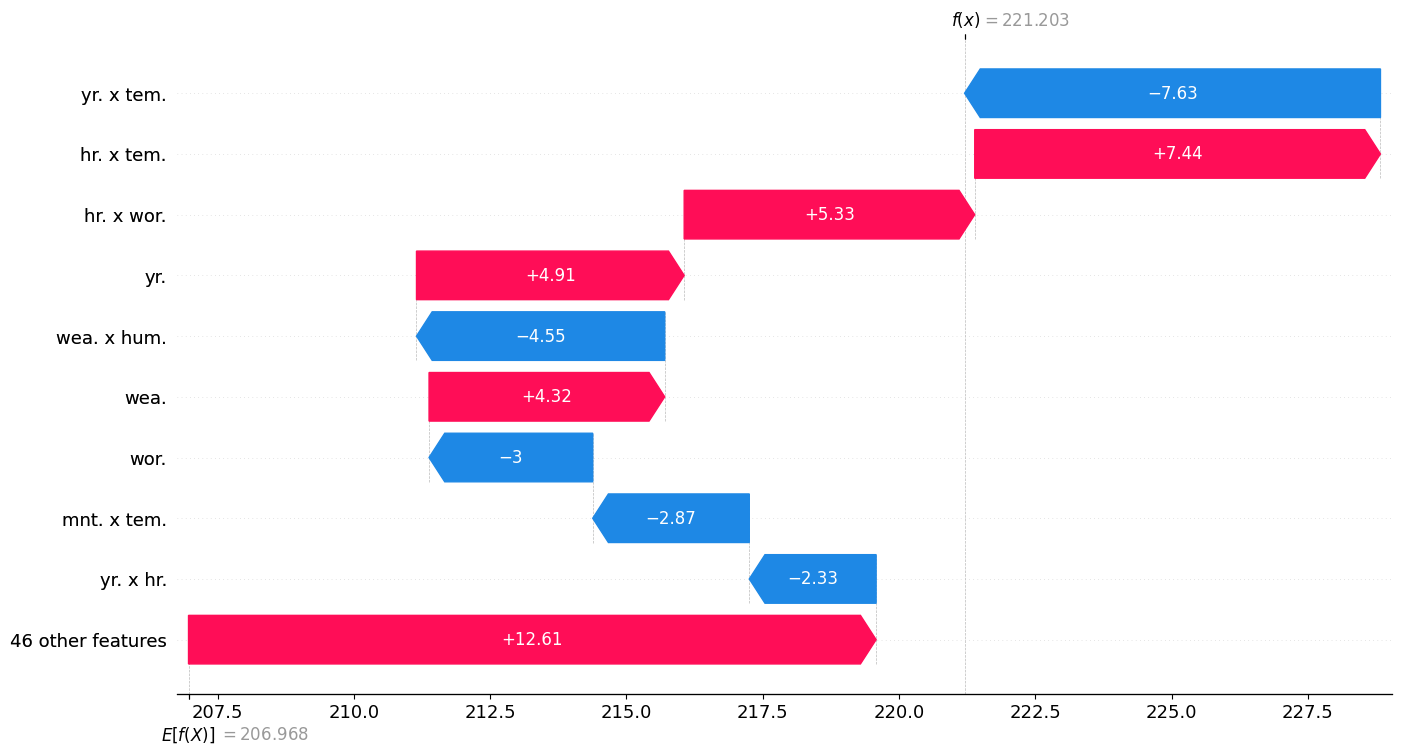

In [80]:
for r, ivs_region in avg_iv.items():
    display(f"Region {r} - rule: {rules[r]}")
    waterfall_plot(ivs_region, show=True, feature_names=features.names())

### UpSet Plot (local plot)
The UpSet plot visualizes the interactions scores as vertical bars and adds a matrix that shows which features are involved in each interaction. The UpSet plot is quite well-known visualization for sets.

'Region 0 - rule: hr<=10.00'

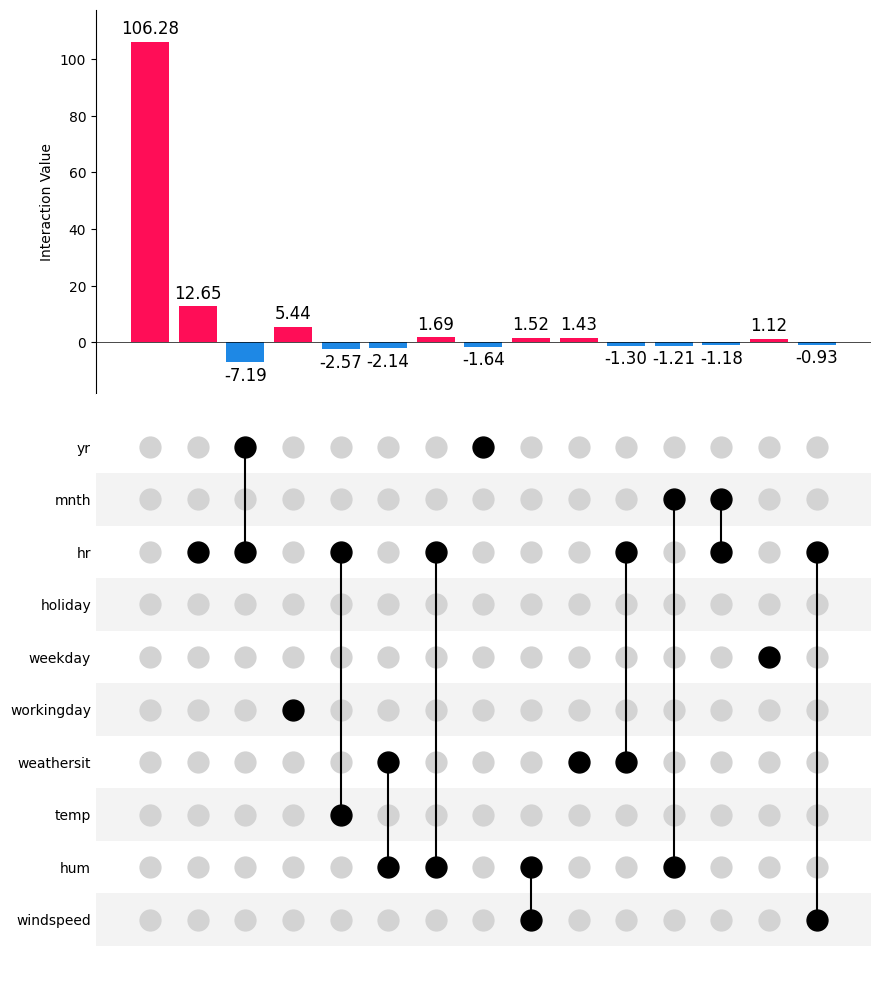

'Region 1 - rule: (hr>10.00 & mnth ∈ {Jan,Feb})'

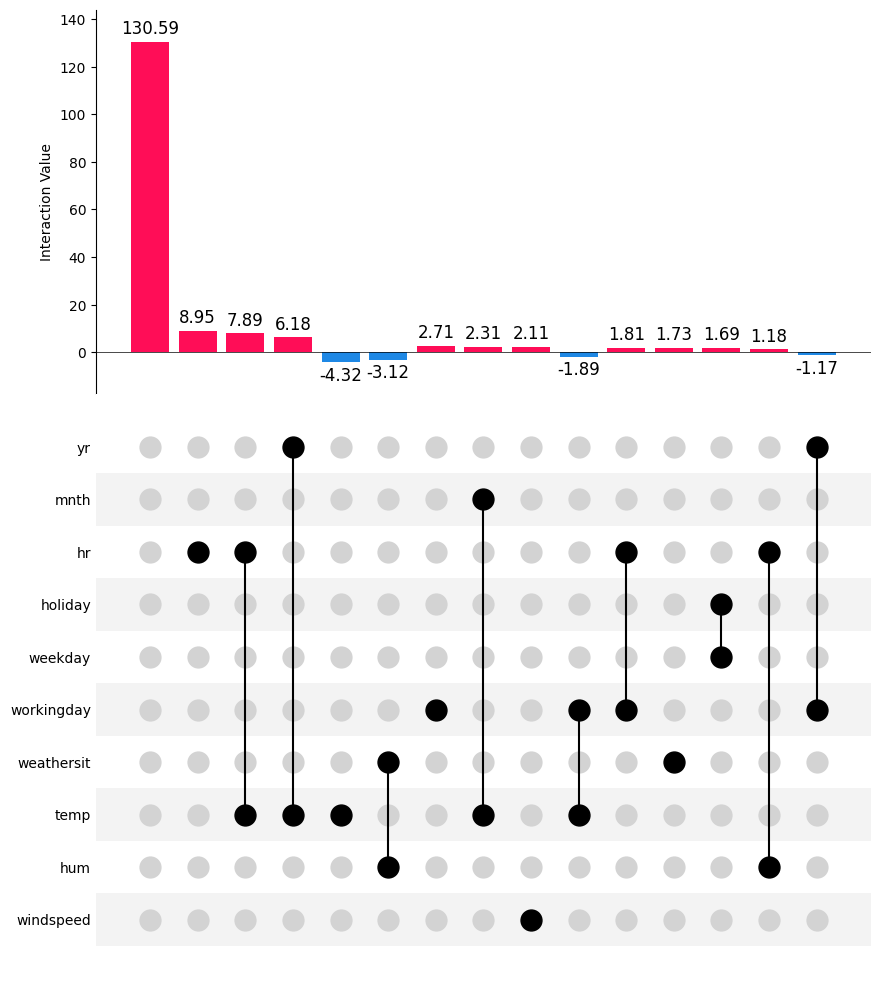

'Region 2 - rule: (hr>10.00 & mnth ∈ {Mar,Apr,May,Jun,Jul,Aug,Sep,Oct})'

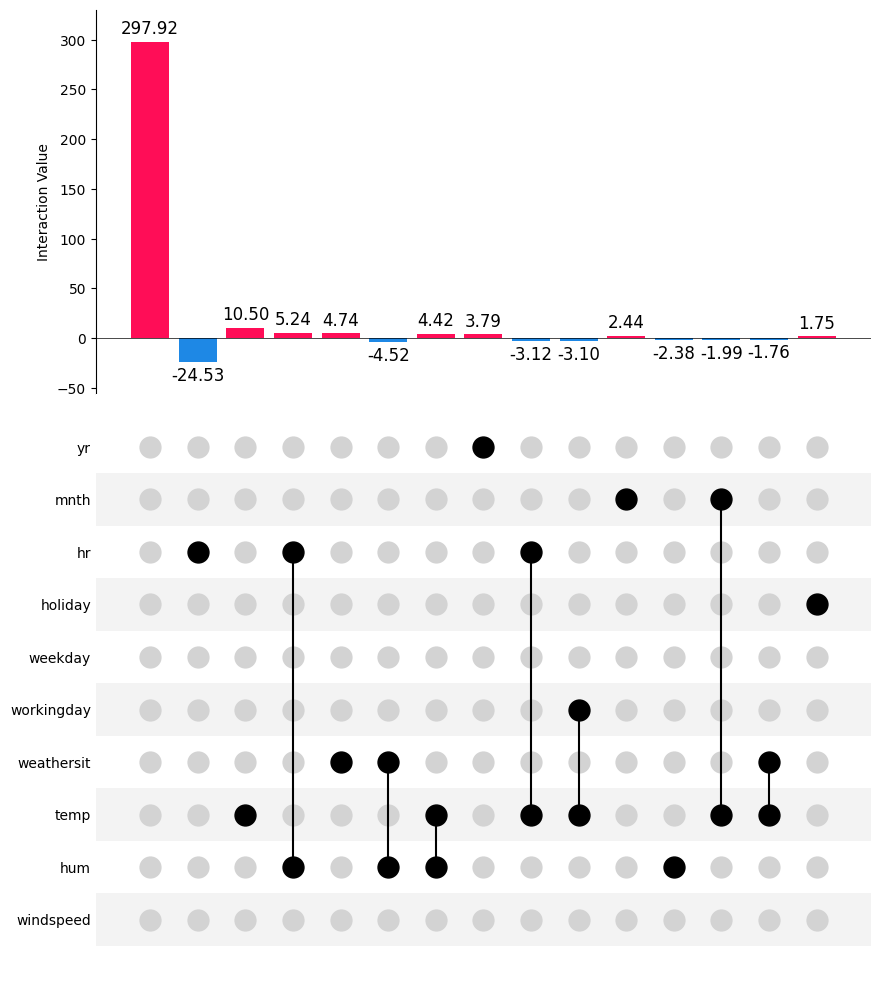

'Region 3 - rule: (hr>10.00 & mnth ∈ {Nov,Dec})'

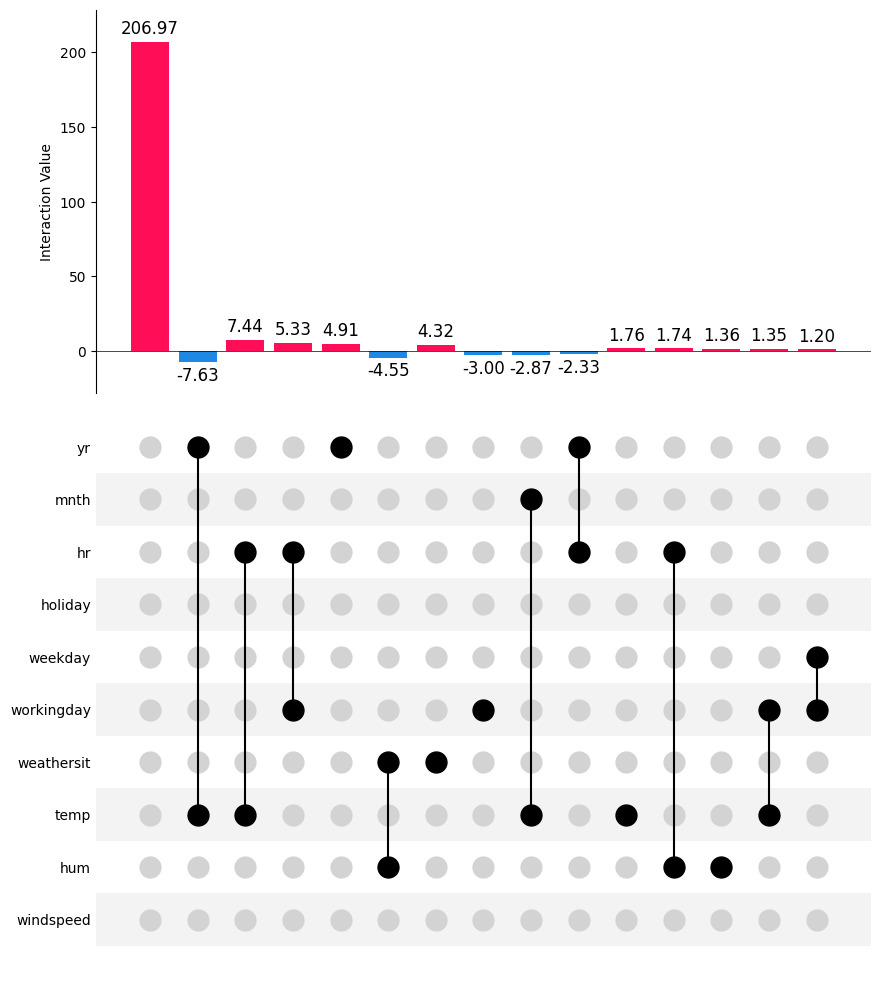

In [81]:
for r, ivs_region in avg_iv.items():
    display(f"Region {r} - rule: {rules[r]}")
    upset_plot(ivs_region, show=True, feature_names=features.names(), n_interactions=15)